In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Cleaned_data.csv")
df.shape

(51271, 22)

Total Sales

In [5]:
total_sales = df['sales'].sum()
print(f"Total Sales: {total_sales:,}")

Total Sales: 12,635,222


Total Profit

In [6]:
total_profit = df['profit'].sum()
print(f"Total Profit: {total_profit:,.2f}")

Total Profit: 1,467,807.48


Average Discount

In [9]:
avg_discount = df['discount'].mean()
print(f"Average Discount: {avg_discount:.2%}")

Average Discount: 14.29%


Top 5 Products by Sales

In [10]:
top5_sales = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print(top5_sales)

product_name
Apple Smart Phone, Full Size             86936
Cisco Smart Phone, Full Size             76441
Motorola Smart Phone, Full Size          73159
Nokia Smart Phone, Full Size             71904
Canon imageCLASS 2200 Advanced Copier    61600
Name: sales, dtype: int64


Top 5 Loss-Making Products

In [11]:
top5_losses = (
    df.groupby('product_name')['profit']
    .sum()
    .sort_values()
    .head(5)
)
print(top5_losses)

product_name
Cubify CubeX 3D Printer Double Head Print   -8879.9704
Lexmark MX611dhe Monochrome Laser Printer   -4589.9730
Motorola Smart Phone, Cordless              -4447.0380
Cubify CubeX 3D Printer Triple Head Print   -3839.9904
Bevis Round Table, Adjustable Height        -3649.8940
Name: profit, dtype: float64


In [12]:
df[df['product_name'] == top5_losses.index[0]].sort_values('profit')

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_estimated
31881,CA-2013-108196,2013-11-26,2013-12-03,Standard Class,Cindy Stewart,Consumer,Ohio,United States,Us,East,...,Machines,Cubify CubeX 3D Printer Double Head Print,4500,5,0.7,-6599.9780,451.63,Low,2013,False
19251,CA-2012-147830,2012-12-15,2012-12-18,First Class,Natalie Fritzler,Consumer,Ohio,United States,Us,East,...,Machines,Cubify CubeX 3D Printer Double Head Print,1800,2,0.7,-2639.9912,219.62,High,2012,False
36559,CA-2014-149881,2014-04-02,2014-04-04,First Class,Nick Crebassa,Corporate,California,United States,Us,West,...,Machines,Cubify CubeX 3D Printer Double Head Print,4800,2,0.2,359.9988,10.34,Medium,2014,False


Region-wise Sales

In [13]:
region_sales = (
    df.groupby('region')['sales']
    .sum()
    .sort_values(ascending=False)
)
print(region_sales)

region
Central           2821740
South             1600600
North             1248121
Oceania           1098253
Southeast Asia     883702
North Asia         846991
Emea               805053
Africa             783345
Central Asia       752839
West               725514
East               678548
Caribbean          323584
Canada              66932
Name: sales, dtype: int64


In [14]:
region_sales_pct = (region_sales / total_sales * 100).round(2)
print(region_sales_pct)

region
Central           22.33
South             12.67
North              9.88
Oceania            8.69
Southeast Asia     6.99
North Asia         6.70
Emea               6.37
Africa             6.20
Central Asia       5.96
West               5.74
East               5.37
Caribbean          2.56
Canada             0.53
Name: sales, dtype: float64


In [15]:
# Category-wise Sales and Profit
category_analysis = df.groupby('category').agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum')
).reset_index()

category_analysis

,category,Total_Sales,Total_Profit
0,Furniture,4105771,286180.690530
1,Office Supplies,3786476,518327.747749
2,Technology,4742975,663299.038954


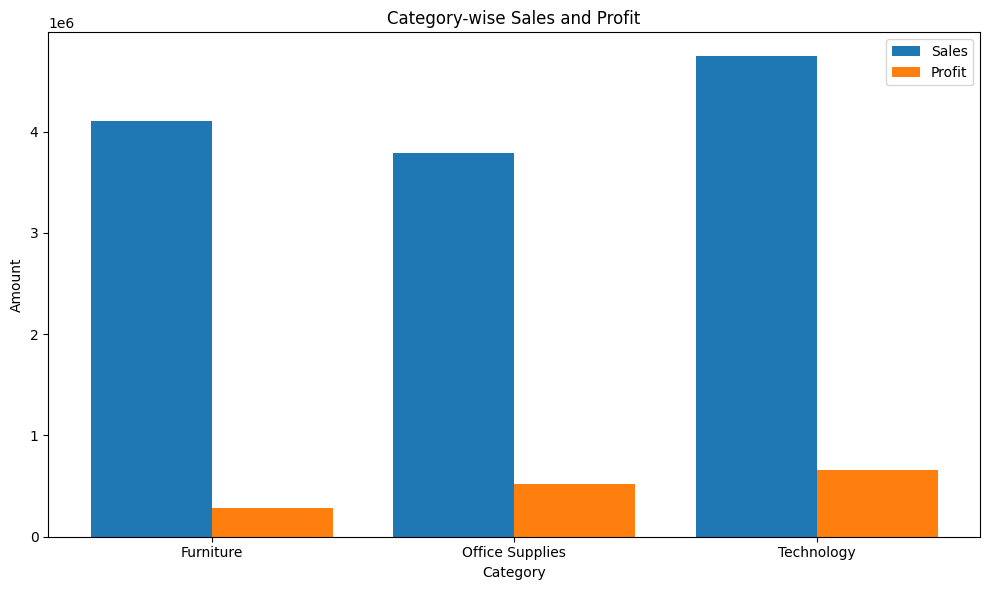

In [18]:
plt.figure(figsize=(10, 6))

x = range(len(category_analysis))

plt.bar(
    [i - 0.2 for i in x],
    category_analysis['Total_Sales'],
    width=0.4,
    label='Sales'
)

plt.bar(
    [i + 0.2 for i in x],
    category_analysis['Total_Profit'],
    width=0.4,
    label='Profit'
)

plt.xticks(x, category_analysis['category'])
plt.xlabel('Category')
plt.ylabel('Amount')
plt.title('Category-wise Sales and Profit')
plt.legend()
plt.tight_layout()
plt.show()

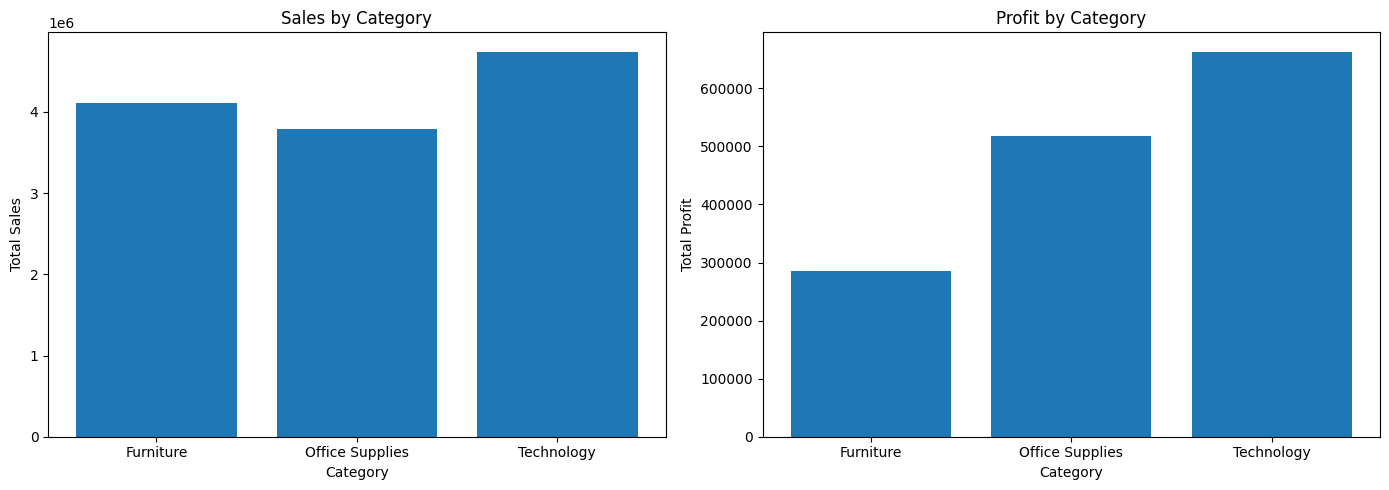

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(category_analysis['category'], category_analysis['Total_Sales'])
ax[0].set_title('Sales by Category')
ax[0].set_xlabel('Category')
ax[0].set_ylabel('Total Sales')

ax[1].bar(category_analysis['category'], category_analysis['Total_Profit'])
ax[1].set_title('Profit by Category')
ax[1].set_xlabel('Category')
ax[1].set_ylabel('Total Profit')

plt.tight_layout()
plt.show()

In [20]:
# Calculate Profit Margin by Category
category_analysis['Profit_Margin_%'] = (
    category_analysis['Total_Profit'] /
    category_analysis['Total_Sales']
) * 100

category_analysis

,category,Total_Sales,Total_Profit,Profit_Margin_%
0,Furniture,4105771,286180.690530,6.970206
1,Office Supplies,3786476,518327.747749,13.688922
2,Technology,4742975,663299.038954,13.984873


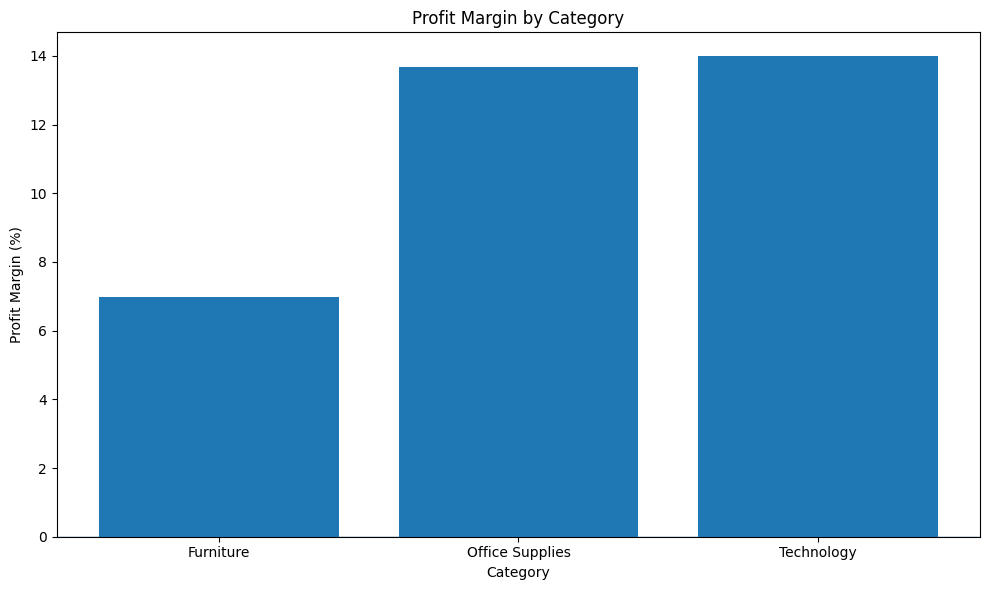

In [21]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis['category'],
    category_analysis['Profit_Margin_%']
)

plt.xlabel('Category')
plt.ylabel('Profit Margin (%)')
plt.title('Profit Margin by Category')

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [22]:
yearly_sales = df.groupby('year').agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum')
).reset_index()

yearly_sales

,year,Total_Sales,Total_Profit
0,2011,2259569,248982.814133
1,2012,2677479,307411.879100
2,2013,3404254,408261.438980
3,2014,4293920,503151.345020


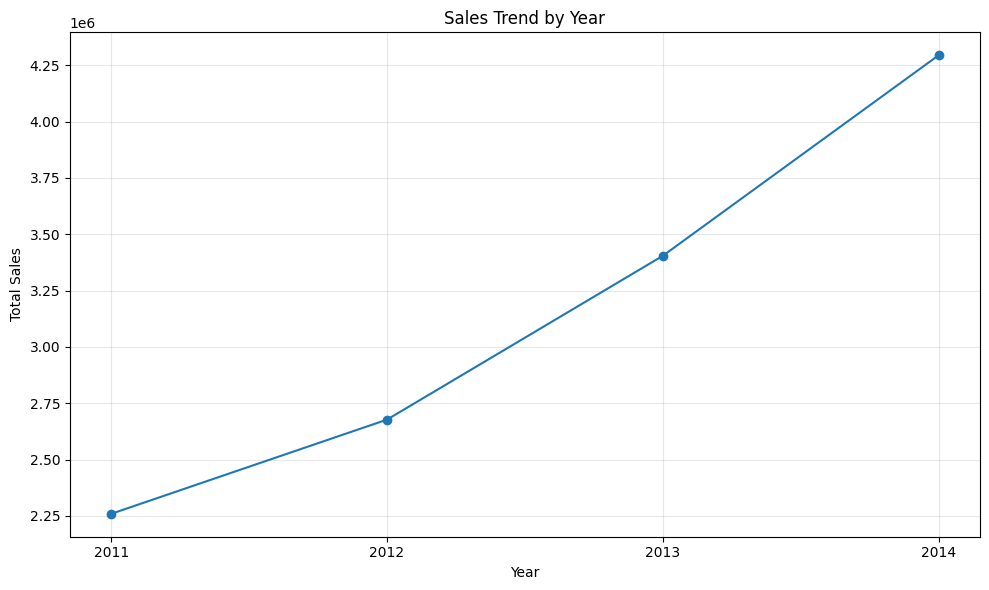

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_sales['year'],
    yearly_sales['Total_Sales'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Sales Trend by Year')
plt.xticks(yearly_sales['year'])

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
segment_analysis = df.groupby('segment').agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum')
).reset_index()

segment_analysis

,segment,Total_Sales,Total_Profit
0,Consumer,6503476,748511.146823
1,Corporate,3822954,442113.274242
2,Home Office,2308792,277183.056168


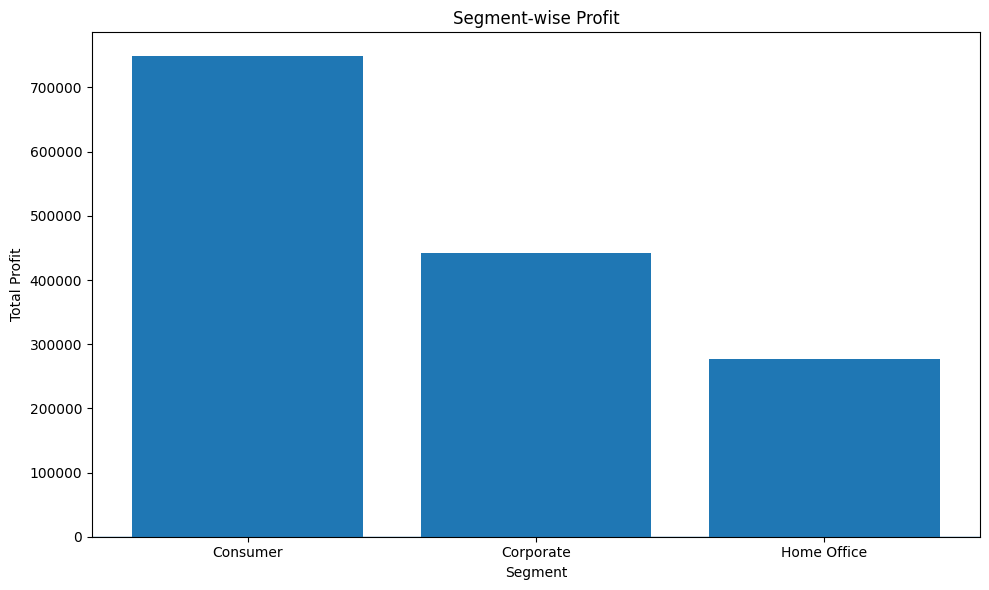

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis['segment'],
    segment_analysis['Total_Profit']
)

plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.title('Segment-wise Profit')

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

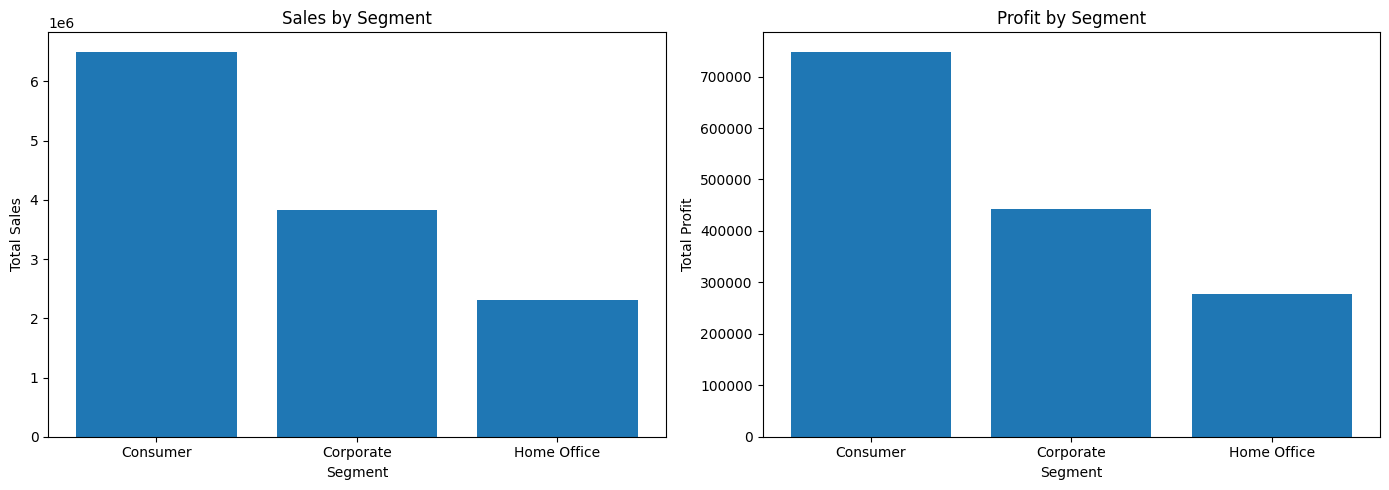

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(
    segment_analysis['segment'],
    segment_analysis['Total_Sales']
)

ax[0].set_title('Sales by Segment')
ax[0].set_xlabel('Segment')
ax[0].set_ylabel('Total Sales')

ax[1].bar(
    segment_analysis['segment'],
    segment_analysis['Total_Profit']
)

ax[1].set_title('Profit by Segment')
ax[1].set_xlabel('Segment')
ax[1].set_ylabel('Total Profit')

plt.tight_layout()
plt.show()